In [1]:
# Data analysis
import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")

Imports successful!


In [5]:
# Create an API call to the NOAA NCEI database
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'
           '?dataset=daily-summaries'
           '&dataTypes=TOBS'
           '&stations=USC00353770'
           '&startDate=1893-10-01'
           '&endDate=2026-07-15'
           '&units=standard')
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00353770&startDate=1893-10-01&endDate=2026-07-15&units=standard'

In [6]:
# Open and clean the data
portland_df = pd.read_csv(
    ncei_url,
    na_values=["-99"],
    index_col="DATE",
    parse_dates=["DATE"]
)
portland_df

,STATION,TOBS
DATE,,
1899-04-01,USC00353770,NaN
1899-04-02,USC00353770,NaN
1899-04-03,USC00353770,NaN
1899-04-04,USC00353770,NaN
1899-04-05,USC00353770,NaN
...,...,...
2026-07-11,USC00353770,NaN
2026-07-12,USC00353770,NaN
2026-07-13,USC00353770,NaN


In [7]:
# Keep only the TOBS column
portland_df = portland_df[["TOBS"]]
portland_df.head()
portland_df.tail()

,TOBS
DATE,
2026-07-11,NaN
2026-07-12,NaN
2026-07-13,NaN
2026-07-14,NaN
2026-07-15,NaN


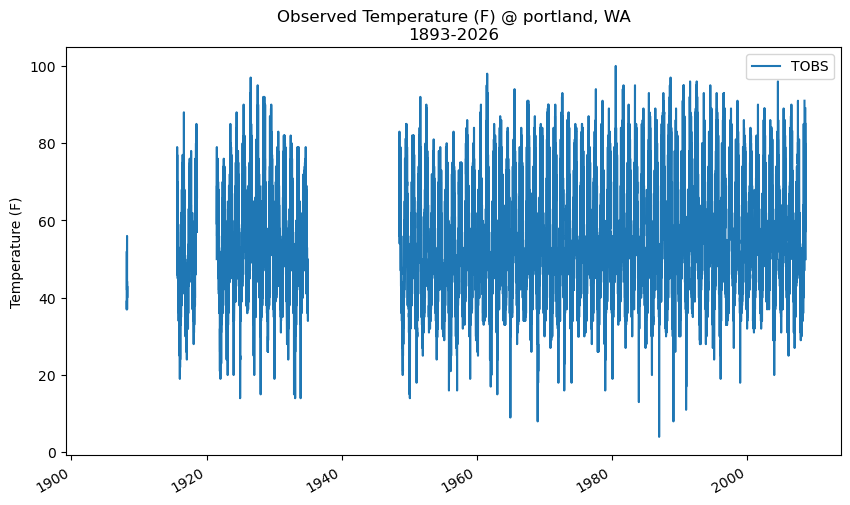

In [8]:
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
portland_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='',
                 title='Observed Temperature (F) @ portland, WA\n1893-2026')
plt.show()

In [9]:
# Take the annual mean of the temperature data
ann_climate_df = portland_df.resample('YE').mean()
ann_climate_df

,TOBS
DATE,
1899-12-31,NaN
1900-12-31,NaN
1901-12-31,NaN
1902-12-31,NaN
1903-12-31,NaN
...,...
2022-12-31,NaN
2023-12-31,NaN
2024-12-31,NaN


<Axes: xlabel='DATE'>

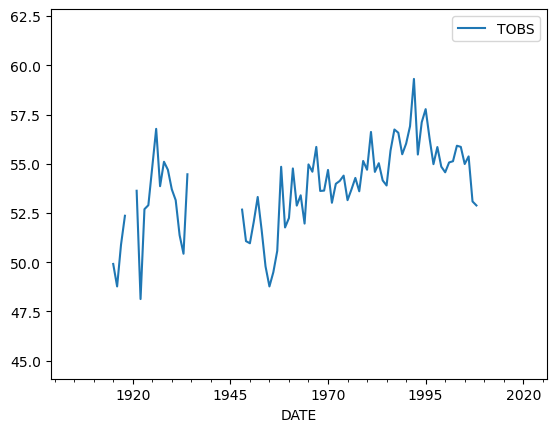

In [10]:
# Plot resampled the data
ann_climate_df.plot()

In [11]:
# Subset the data to look at last 30 years of data
portland_30yr = ann_climate_df.loc["1985":"2005"]
portland_30yr

,TOBS
DATE,
1985-12-31,53.895890
1986-12-31,55.663014
1987-12-31,56.739521
1988-12-31,56.575342
1989-12-31,55.482192
1990-12-31,56.021918
1991-12-31,56.906593
1992-12-31,59.308743
1993-12-31,55.468493


<Axes: xlabel='DATE'>

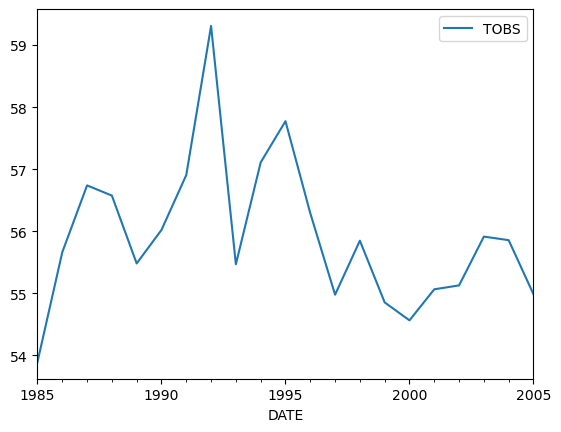

In [12]:
# Plot 30 yrs of data
portland_30yr.plot()

In [16]:
# Create an interactive plot with hvplot
portland_30yr_plot = portland_30yr.hvplot(title='Portland Annual Mean Temp', line_color = "green")
portland_30yr_plot

:Curve   [DATE]   (TOBS)

In [17]:
# Save interactive plot as html to host on the web
hv.save(portland_30yr_plot, 'portland_plot.html')